# Análisis Exploratorio de Datos (EDA) - Predicción de incumplimieto de crédito (loan default prediction)

## Objetivo
Realizar un análisis exploratorio del dataset de incumplimiento de préstamos para:
- Comprender la estructura de los datos,
- Evaluar calidad y consistencia,
- Identificar valores faltantes y outliers,
- Detectar patrones relevantes entre variables explicativas y la variable objetivo `loan_status`.

Este análisis servirá como base para la etapa de preprocesamiento y posterior modelado predictivo.


## Imports

In [52]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")


## Carga de datos

Se carga el dataset desde la carpeta `data/raw` para comenzar el análisis exploratorio.

In [53]:
df = pd.read_csv(r"..\data\raw\credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Inspección general del dataset

Se revisa la estructura general del dataset, incluyendo dimensiones y tipos de datos.

In [54]:
df.shape

(32581, 12)

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


## Estadísticas descriptivas

Se analizan las variables numéricas para entender su comportamiento general.

In [56]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## Descripción de variables del dataset

A continuación se describen las variables utilizadas en el análisis, clasificándolas según su tipo (numérica o categórica) y su significado:

### Variables numéricas

- **person_age**: Edad del solicitante (años).
- **person_income**: Ingreso anual del solicitante.
- **person_emp_length**: Años de experiencia laboral del solicitante.
- **loan_amnt**: Monto del préstamo solicitado.
- **loan_int_rate**: Tasa de interés del préstamo.
- **loan_percent_income**: Proporción del ingreso del solicitante comprometido por el préstamo.
- **cb_person_cred_hist_length**: Longitud del historial crediticio (años).

---

### Variables categóricas

- **person_home_ownership**: Tipo de vivienda del solicitante.
  - RENT: Arrienda
  - OWN: Propietario
  - MORTGAGE: Hipoteca
  - OTHER: Otro tipo

- **loan_intent**: Propósito del préstamo.
  - EDUCATION: Educación
  - MEDICAL: Gastos médicos
  - VENTURE: Negocio/emprendimiento
  - PERSONAL: Uso personal
  - DEBTCONSOLIDATION: Consolidación de deudas
  - HOMEIMPROVEMENT: Mejoras del hogar

- **loan_grade**: Clasificación del préstamo según riesgo crediticio.
  - A: Menor riesgo
  - B–G: Riesgo creciente (G es el más alto)

- **cb_person_default_on_file**: Historial previo de incumplimiento.
  - Y: Sí ha tenido incumplimientos
  - N: No ha tenido incumplimientos

---

### Variable objetivo

- **loan_status**: Estado del préstamo (variable objetivo).
  - 1: Incumplimiento (default)
  - 0: No incumplimiento

---

### Observación

Las variables numéricas permiten modelar relaciones cuantitativas, mientras que las variables categóricas aportan información cualitativa relevante sobre el perfil del solicitante. Estas últimas serán transformadas mediante técnicas de codificación (encoding) para su uso en modelos de aprendizaje automático.

## Valores faltantes

Se identifican valores nulos en el dataset para evaluar su impacto.

In [57]:
df.isnull().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [58]:
(df.isnull().mean() * 100).sort_values(ascending=False)

loan_int_rate                 9.563856
person_emp_length             2.747000
person_income                 0.000000
person_age                    0.000000
person_home_ownership         0.000000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

### Observación
Se observan variables con valores faltantes que deberán ser tratadas en la etapa de preprocesamiento.

## Distribución de la variable objetivo

Se analiza la variable `loan_status` para entender el balance de clases.


In [59]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

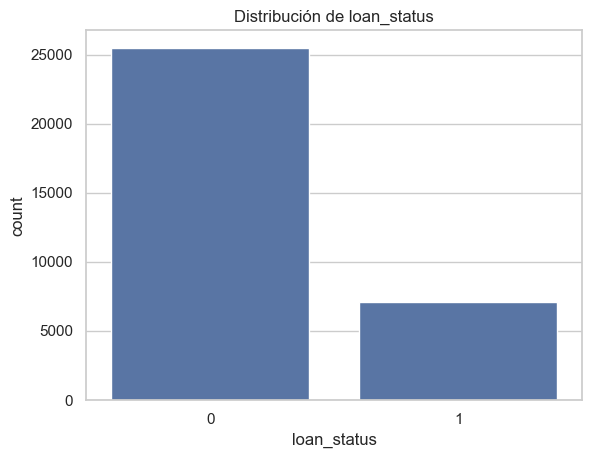

In [60]:
sns.countplot(data=df, x="loan_status")
plt.title("Distribución de loan_status")
plt.show()

### Observación
Existe desbalance entre clases, lo cual puede afectar el entrenamiento de modelos.

## Distribución de variables numéricas

Se visualizan histogramas para analizar la distribución de las variables numéricas.

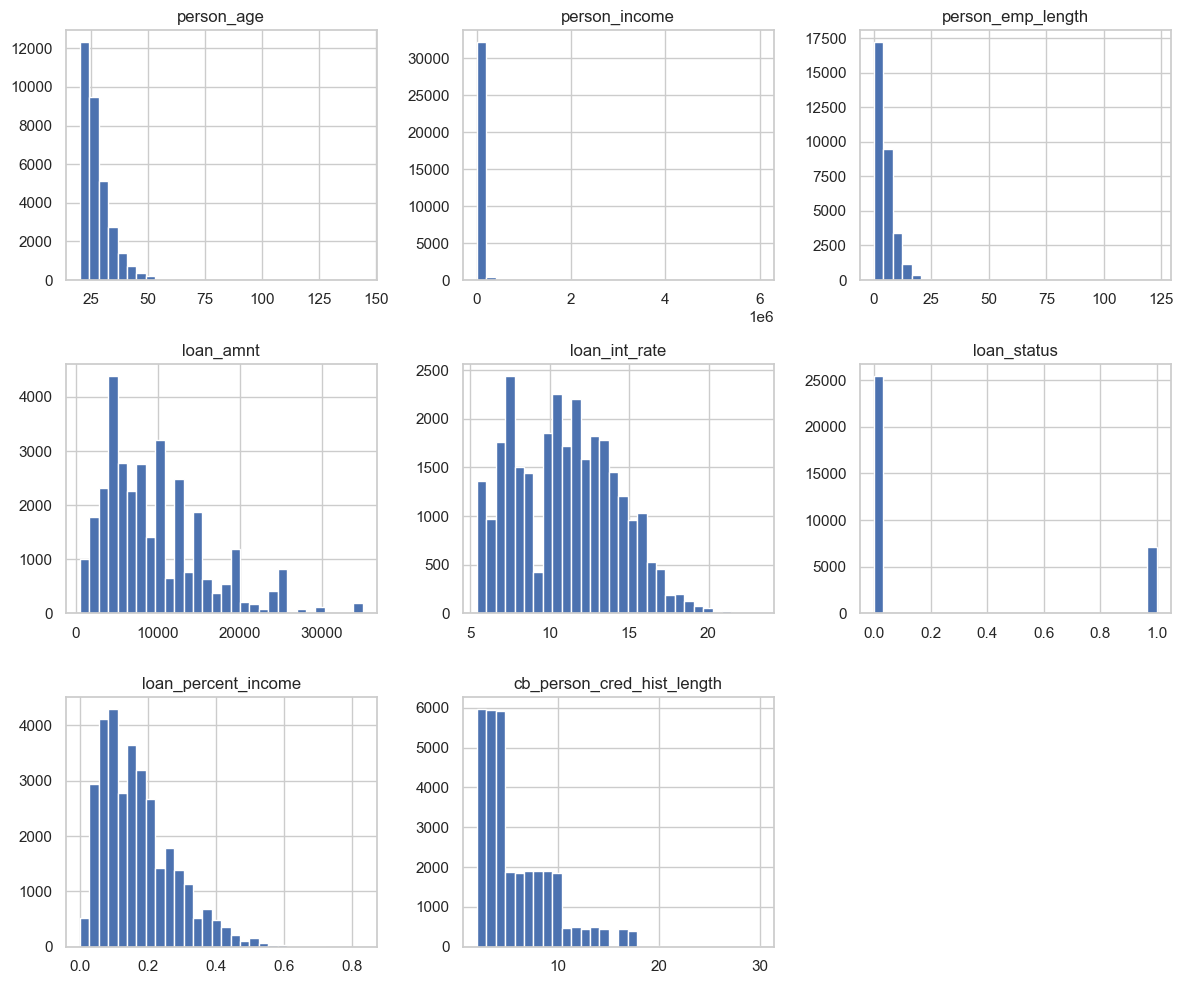

In [61]:
df.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

## Detección de outliers

Se utilizan boxplots para identificar valores atípicos.

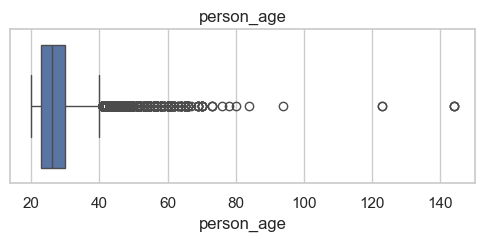

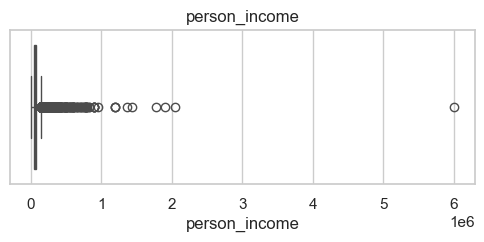

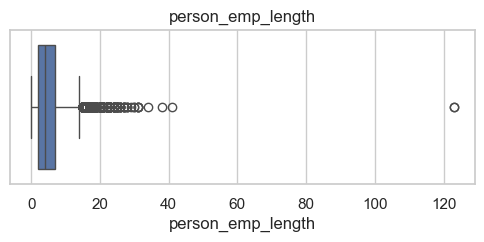

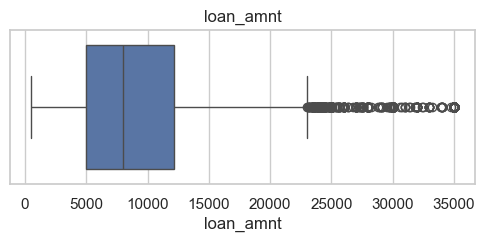

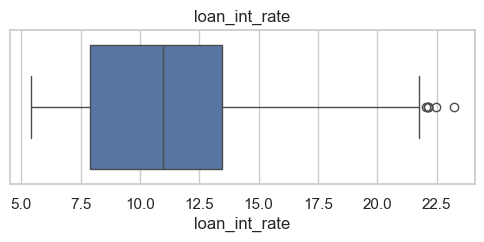

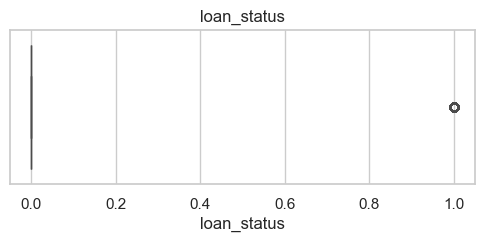

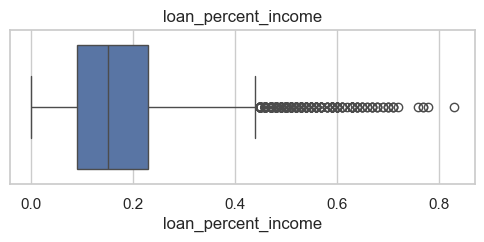

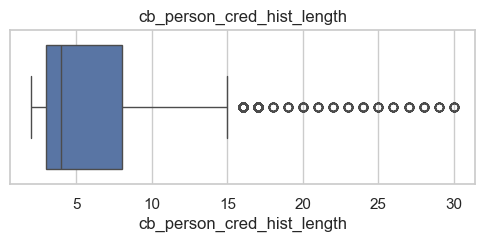

In [62]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Observación

Se detectan valores extremos en variables como ingresos y montos de préstamo, los cuales deberán analizarse en el preprocesamiento.

## Relación entre variables y loan_status

Se analiza cómo algunas variables influyen en el incumplimiento.

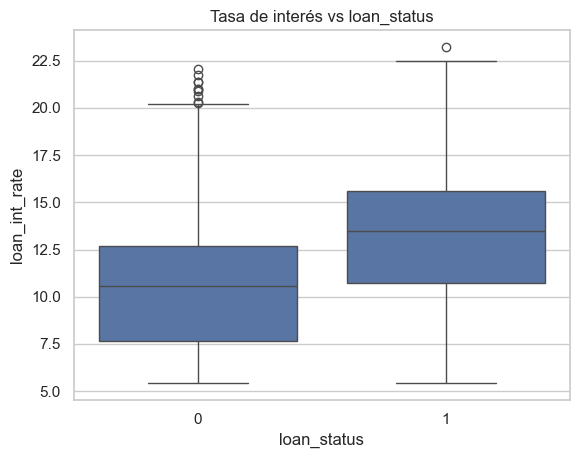

In [63]:
sns.boxplot(data=df, x="loan_status", y="loan_int_rate")
plt.title("Tasa de interés vs loan_status")
plt.show()

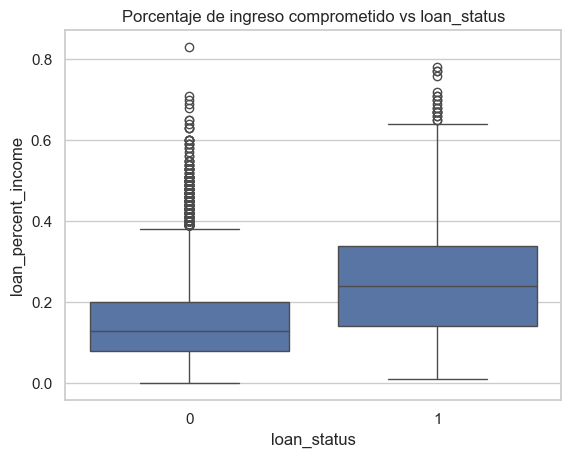

In [64]:
sns.boxplot(data=df, x="loan_status", y="loan_percent_income")
plt.title("Porcentaje de ingreso comprometido vs loan_status")
plt.show()

### Observación
Se observa que mayores tasas de interés y mayor proporción de ingreso comprometido se asocian con mayor probabilidad de incumplimiento en el pago del crédito.

## Variables categóricas

Se analizan variables categóricas en relación con la variable objetivo.

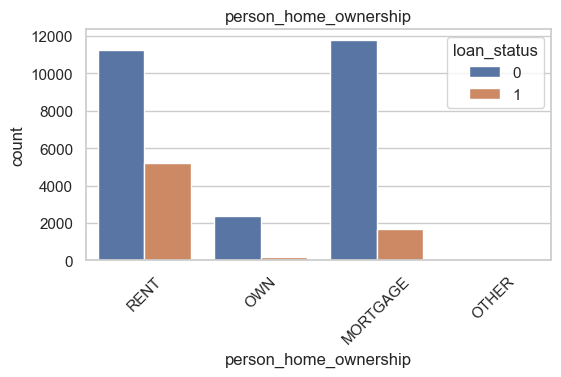

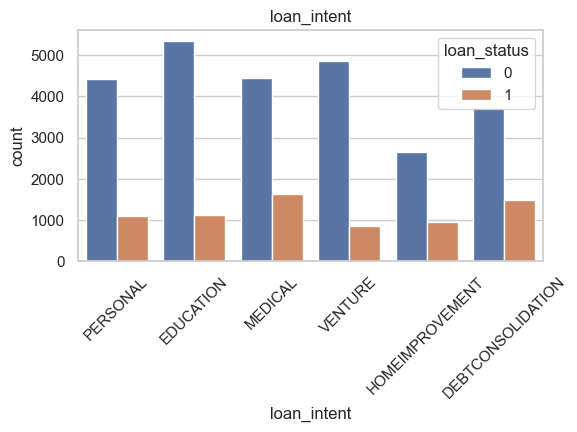

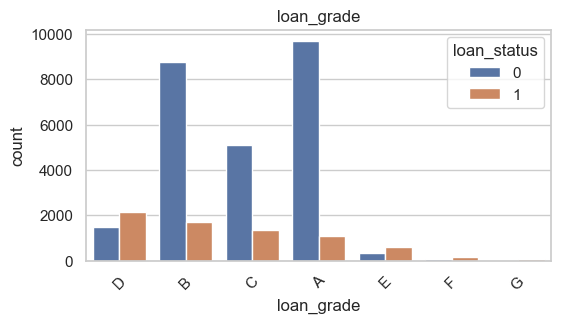

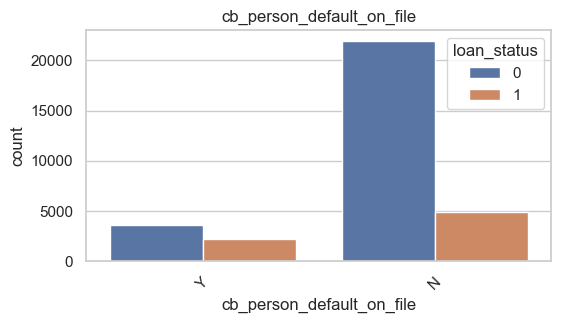

In [65]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(data=df, x=col, hue="loan_status")
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

### Observación
Algunas categorías muestran diferencias claras entre clientes con y sin incumplimiento.

## Correlación entre variables

Se analiza la relación entre variables numéricas.

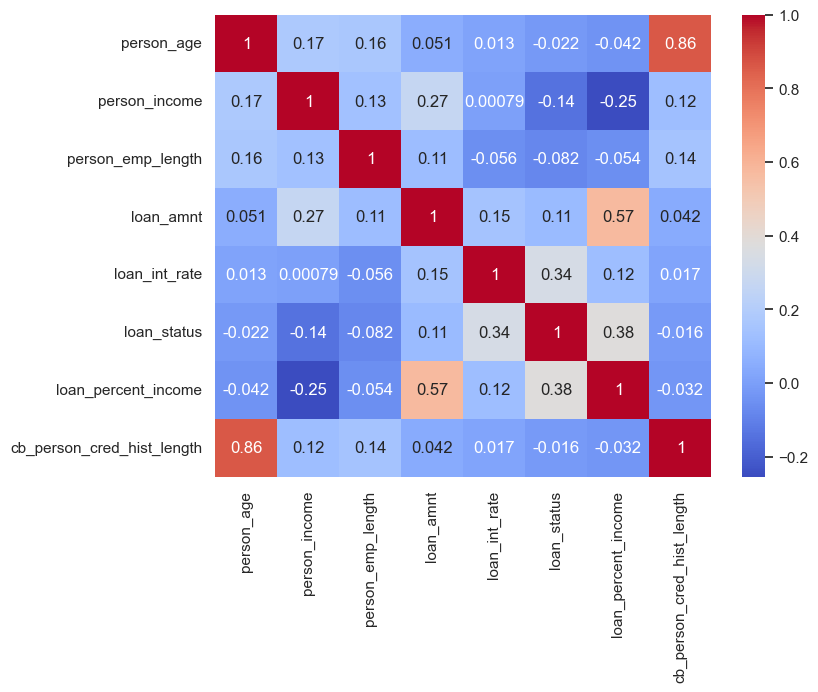

In [66]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


## Conclusiones del análisis exploratorio

El análisis exploratorio permitió comprender en profundidad la estructura y calidad del dataset, así como identificar patrones relevantes para la predicción del incumplimiento de préstamos.

En primer lugar, se detectó la presencia de valores faltantes en algunas variables, lo que hizo necesario considerar técnicas de imputación en la etapa de preprocesamiento para evitar la pérdida de información relevante. Asimismo, se identificaron outliers en variables numéricas como ingresos, monto del préstamo y tasa de interés, los cuales podrían influir en el comportamiento del modelo, por lo que se evaluó su impacto antes de decidir su tratamiento.

En cuanto a la variable objetivo, se observa un cierto nivel de desbalance entre las clases, lo que puede afectar el rendimiento del modelo, especialmente en la detección de casos de incumplimiento. Este aspecto es importante ya que influye directamente en la elección de métricas y técnicas de modelado.

A partir del análisis de correlación, se identifican relaciones relevantes entre variables. Por ejemplo, `loan_percent_income` y `loan_int_rate` presentan una relación positiva con el incumplimiento, lo que sugiere que una mayor carga financiera y tasas de interés más elevadas están asociadas a un mayor riesgo. También se observa una relación entre la edad y la longitud del historial crediticio, lo cual podría implicar cierta redundancia de información.

Estos hallazgos permitieron orientar las decisiones de preprocesamiento y modelado, priorizando variables con mayor relevancia predictiva y considerando posibles transformaciones para mejorar el desempeño de los modelos.

En conjunto, el análisis exploratorio confirma que el dataset contiene señales útiles para abordar el problema de clasificación y sienta las bases para una etapa de modelado más informada.


## Preprocesamiento de datos

En esta sección se preparan los datos para el modelado:
- Tratamiento de valores faltantes
- Codificación de variables categóricas
- Escalamiento de variables numéricas
- Partición en conjuntos de entrenamiento y prueba

Se evita fuga de información aplicando transformaciones **solo a los datos de entrenamiento**.

### Selección de variables

Se define la variable objetivo (`loan_status`) y el conjunto de variables explicativas.

In [67]:
target = "loan_status"

X = df.drop(columns=[target])
y = df[target].copy()

X.shape, y.shape

((32581, 11), (32581,))

### División en entrenamiento y prueba

Se divide el dataset para evitar fuga de información durante el preprocesamiento.

In [68]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # mantiene proporción de clases
)

X_train.shape, X_test.shape

((26064, 11), (6517, 11))

### Identificación de variables numéricas y categóricas

In [69]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

num_cols, cat_cols

(['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length'],
 ['person_home_ownership',
  'loan_intent',
  'loan_grade',
  'cb_person_default_on_file'])

### Tratamiento de valores faltantes

- Numéricas: imputación con mediana  
- Categóricas: imputación con moda (más frecuente)

In [70]:
# Crear imputadores:
# - mediana para variables numéricas (robusto a outliers)
# - valor más frecuente para variables categóricas
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

# Ajustar imputador numérico SOLO con entrenamiento y transformar
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[num_cols]),  # aprende y aplica
    columns=num_cols,
    index=X_train.index
)

# Aplicar imputación al test (sin volver a ajustar)
X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

# Ajustar imputador categórico SOLO con entrenamiento y transformar
X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train[cat_cols]),
    columns=cat_cols,
    index=X_train.index
)

# Aplicar imputación categórica al test
X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test[cat_cols]),
    columns=cat_cols,
    index=X_test.index
)

### Codificación de variables categóricas

Se aplica One-Hot Encoding para transformar variables categóricas en variables numéricas.

In [71]:
from sklearn.preprocessing import OneHotEncoder

# Crear encoder para variables categóricas
# handle_unknown="ignore" evita errores si aparece una categoría nueva en test
# sparse_output=False devuelve un array denso (no disperso)
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Ajustar encoder con datos de entrenamiento y transformar
X_train_cat_enc = pd.DataFrame(
    encoder.fit_transform(X_train_cat),  # aprende categorías y transforma
    columns=encoder.get_feature_names_out(cat_cols),  # nombres de nuevas columnas
    index=X_train.index
)

# Aplicar transformación al conjunto de prueba (sin volver a ajustar)
X_test_cat_enc = pd.DataFrame(
    encoder.transform(X_test_cat),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

### Escalamiento de variables numéricas

Se aplica StandardScaler para normalizar las variables numéricas.

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=num_cols,
    index=X_train.index
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num),
    columns=num_cols,
    index=X_test.index
)

### Construcción del dataset final

In [73]:
X_train_final = pd.concat([X_train_num_scaled, X_train_cat_enc], axis=1)
X_test_final = pd.concat([X_test_num_scaled, X_test_cat_enc], axis=1)

X_train_final.shape, X_test_final.shape

((26064, 26), (6517, 26))

### Verificación del dataset

In [74]:
X_train_final.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
15884,-0.427163,2.759666,-0.187630,1.021455,-1.288396,-0.937956,-0.442817,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15138,-1.059358,-0.754040,0.055383,-1.281664,0.379327,-0.844328,-0.442817,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7474,-0.427163,-0.204717,1.270449,1.021455,0.493109,1.215493,-0.938514,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18212,0.046983,-0.772874,-0.187630,-0.725739,0.964493,1.215493,0.548578,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6493,-0.427163,-0.251802,-0.673657,0.068440,-1.012068,0.279211,-0.938514,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [75]:
X_train_final.isnull().sum().sum()

np.int64(0)

### Exportación de datos procesados

Se guardan los datasets para su uso en el modelado.

In [76]:
import os
os.makedirs(r"..\data\processed", exist_ok=True)

X_train_final.to_csv(r"..\data\processed\X_train.csv", index=False)
X_test_final.to_csv(r"..\data\processed\X_test.csv", index=False)
y_train.to_csv(r"..\data\processed\y_train.csv", index=False)
y_test.to_csv(r"..\data\processed\y_test.csv", index=False)

## Refinamiento iterativo del modelado

        En esta segunda iteración se mantiene el enfoque original del proyecto, pero se amplía la comparación experimental para responder mejor a la rúbrica. Además de Regresión Logística, Árbol de Decisión y Random Forest, se incorporan Gradient Boosting y tres configuraciones MLP usando `MLPClassifier` de `scikit-learn`.

        El objetivo no es forzar un modelo más complejo, sino comparar alternativas de forma trazable y justificar por qué Random Forest sigue siendo una opción equilibrada para datos tabulares de riesgo crediticio.

In [79]:
from pathlib import Path
import json
import time

import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

ASSETS_DIR = Path("..") / ".generated_assets"
ASSETS_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

### Pipeline reproducible de preprocesamiento

        Se define un `ColumnTransformer` para integrar imputación, escalamiento y codificación categórica. Esto permite entrenar y exportar un pipeline completo, de modo que la app Dash pueda recibir datos crudos sin depender de transformaciones manuales externas.

In [80]:
target = "loan_status"

X = df.drop(columns=[target])
y = df[target].copy()

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

def build_preprocessor():
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print(y_train.value_counts(normalize=True))

Train: (26064, 11)
Test: (6517, 11)
loan_status
0    0.781845
1    0.218155
Name: proportion, dtype: float64


### Comparación ampliada de modelos ML y MLP

        Se comparan siete modelos con las mismas particiones de entrenamiento y prueba. Las métricas usadas son Accuracy, Precision, Recall, F1-score, ROC-AUC y tiempo de entrenamiento.

In [81]:
def evaluar_pipeline(nombre, pipeline, X_train, X_test, y_train, y_test):
    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    train_time = time.perf_counter() - start

    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Tiempo_entrenamiento_seg": train_time
    }, pipeline

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLP simple": MLPClassifier(hidden_layer_sizes=(32,), max_iter=120, early_stopping=True, random_state=RANDOM_STATE),
    "MLP profunda": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=120, early_stopping=True, random_state=RANDOM_STATE),
    "MLP regularizada": MLPClassifier(hidden_layer_sizes=(64, 32), alpha=0.01, max_iter=120, early_stopping=True, random_state=RANDOM_STATE),
}

resultados_modelos = []
modelos_entrenados = {}

for nombre, estimador in modelos.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("model", estimador)
    ])
    resultado, entrenado = evaluar_pipeline(nombre, pipeline, X_train, X_test, y_train, y_test)
    resultados_modelos.append(resultado)
    modelos_entrenados[nombre] = entrenado

comparacion_modelos = pd.DataFrame(resultados_modelos).sort_values("F1", ascending=False)
comparacion_modelos.to_csv(ASSETS_DIR / "comparacion_modelos_ml_dl.csv", index=False)
comparacion_modelos

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Tiempo_entrenamiento_seg
2,Random Forest,0.933098,0.965094,0.719409,0.824335,0.929216,1.380948
3,Gradient Boosting,0.926960,0.948767,0.703235,0.807754,0.926226,1.870123
6,MLP regularizada,0.918981,0.922495,0.686357,0.787097,0.919049,1.219906
5,MLP profunda,0.919441,0.941003,0.672996,0.784748,0.919468,1.589189
4,MLP simple,0.915145,0.915789,0.672996,0.775841,0.914939,0.915651
1,Decision Tree,0.899647,0.975248,0.554149,0.706726,0.872756,0.050106
0,Logistic Regression,0.867117,0.766795,0.561885,0.648539,0.869339,0.064767


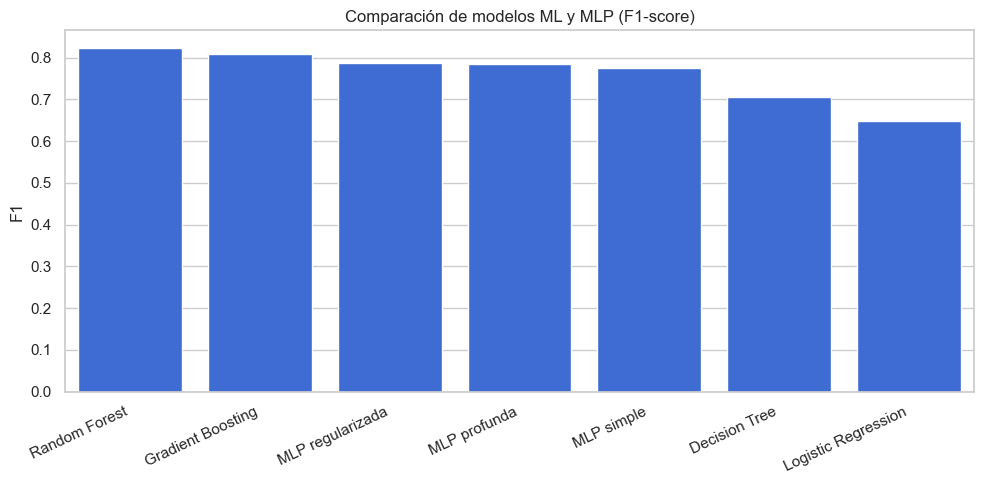

In [82]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparacion_modelos, x="Modelo", y="F1", color="#2563EB")
plt.title("Comparación de modelos ML y MLP (F1-score)")
plt.xlabel("")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "grafico_modelos.png", dpi=160)
plt.show()

### Interpretación de la comparación

        La comparación ampliada confirma que Random Forest mantiene el mejor equilibrio general entre desempeño, estabilidad e interpretabilidad para este dataset tabular. Gradient Boosting se comporta como una alternativa competitiva, mientras que las arquitecturas MLP muestran resultados razonables, pero no superan a Random Forest en F1-score ni aportan la misma facilidad de interpretación.

        Esto no implica que las redes neuronales sean inadecuadas; más bien, en este problema concreto requieren mayor ajuste y recursos para competir con modelos de ensamble diseñados para datos tabulares.

### Comparación de técnicas de balanceo

        Se evalúa el impacto de cuatro estrategias sobre Random Forest: sin balanceo, `class_weight`, RandomUnderSampler y SMOTE. La comparación permite observar el trade-off entre precision y recall, especialmente relevante cuando el costo de no detectar un incumplimiento puede ser alto.

In [85]:
estrategias_balanceo = {
    "Sin balanceo": Pipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("model", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1))
    ]),
    "class_weight": Pipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("model", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1))
    ]),
    "RandomUnderSampler": ImbPipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("sampler", RandomUnderSampler(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1))
    ]),
    "SMOTE": ImbPipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("sampler", SMOTE(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1))
    ]),
}

resultados_balanceo = []
modelos_balanceo = {}

for nombre, pipeline in estrategias_balanceo.items():
    resultado, entrenado = evaluar_pipeline(nombre, pipeline, X_train, X_test, y_train, y_test)
    resultado["Tecnica_balanceo"] = nombre
    resultados_balanceo.append(resultado)
    modelos_balanceo[nombre] = entrenado

comparacion_balanceo = pd.DataFrame(resultados_balanceo)
comparacion_balanceo.to_csv(ASSETS_DIR / "comparacion_balanceo.csv", index=False)
comparacion_balanceo

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Tiempo_entrenamiento_seg,Tecnica_balanceo
0,Sin balanceo,0.933098,0.965094,0.719409,0.824335,0.929216,1.398994,Sin balanceo
1,class_weight,0.934786,0.976122,0.718706,0.827866,0.930093,1.352918,class_weight
2,RandomUnderSampler,0.893202,0.736945,0.793952,0.764387,0.927392,0.610757,RandomUnderSampler
3,SMOTE,0.929108,0.929338,0.730661,0.818110,0.928524,2.483312,SMOTE


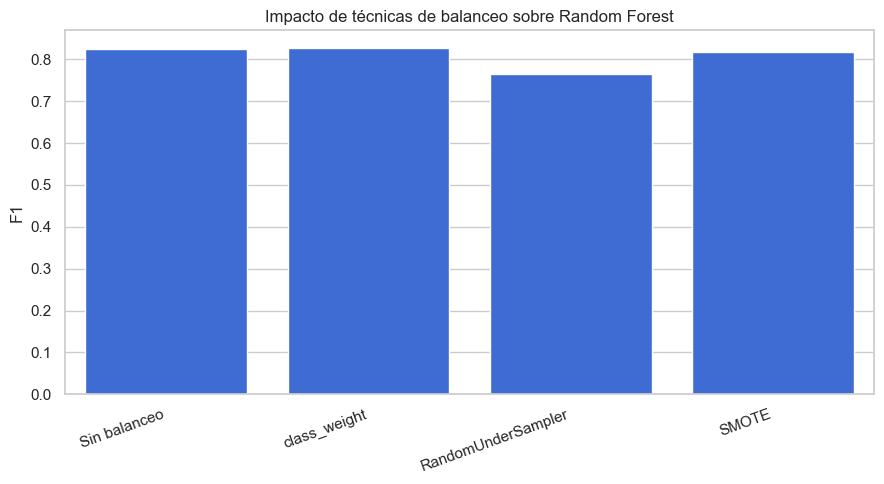

In [86]:
plt.figure(figsize=(9, 5))
sns.barplot(data=comparacion_balanceo, x="Tecnica_balanceo", y="F1", color="#2563EB")
plt.title("Impacto de técnicas de balanceo sobre Random Forest")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "grafico_balanceo.png", dpi=160)
plt.show()

### Threshold tuning

        A partir del Random Forest final se evalúan distintos thresholds de clasificación. Este ajuste permite mover el punto de decisión sin reentrenar el modelo, observando cómo cambian precision, recall y F1-score.

In [88]:
final_pipeline = modelos_balanceo["Sin balanceo"]
y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]

threshold_rows = []
for threshold in np.arange(0.20, 0.81, 0.05):
    y_pred_threshold = (y_proba_final >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": round(float(threshold), 2),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold, zero_division=0),
    })

threshold_tuning = pd.DataFrame(threshold_rows)
threshold_tuning.to_csv(ASSETS_DIR / "threshold_tuning.csv", index=False)

best_threshold = float(
    threshold_tuning.sort_values(["F1", "Recall"], ascending=False).iloc[0]["Threshold"]
)

threshold_tuning

,Threshold,Precision,Recall,F1
0,0.20,0.676048,0.827707,0.744230
1,0.25,0.765741,0.795359,0.780269
2,0.30,0.827068,0.773558,0.799419
3,0.35,0.880757,0.753165,0.811979
4,0.40,0.921861,0.738397,0.819992
5,0.45,0.943482,0.727848,0.821755
6,0.50,0.965094,0.719409,0.824335
7,0.55,0.980658,0.713080,0.825733
8,0.60,0.987205,0.705345,0.822806
9,0.65,0.988967,0.693390,0.815213


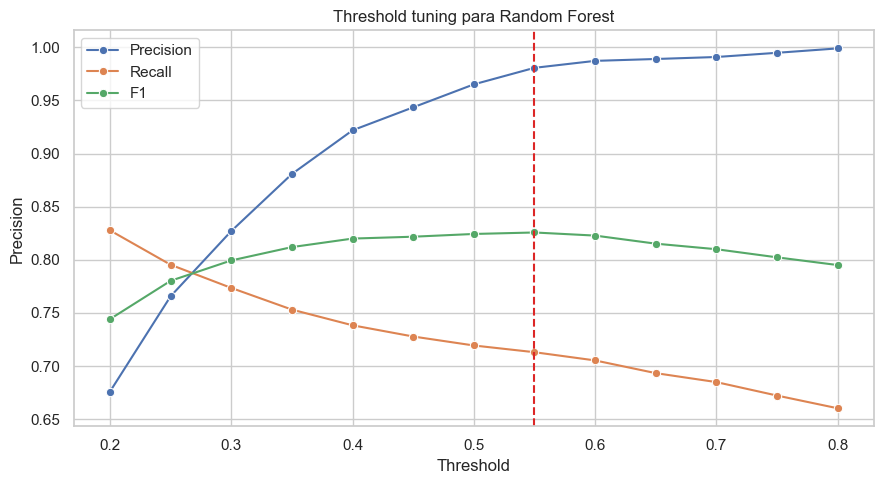

In [89]:
plt.figure(figsize=(9, 5))
for metric in ["Precision", "Recall", "F1"]:
    sns.lineplot(data=threshold_tuning, x="Threshold", y=metric, marker="o", label=metric)

plt.axvline(best_threshold, color="#DC2626", linestyle="--", label=f"Threshold óptimo: {best_threshold:.2f}")
plt.title("Threshold tuning para Random Forest")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "threshold_plot.png", dpi=160)
plt.show()

### Matriz de confusión final y reporte de clasificación

        Se evalúa el modelo final usando el threshold optimizado por F1-score. Esta versión conserva Random Forest como modelo seleccionado, pero mejora la trazabilidad del proceso experimental.

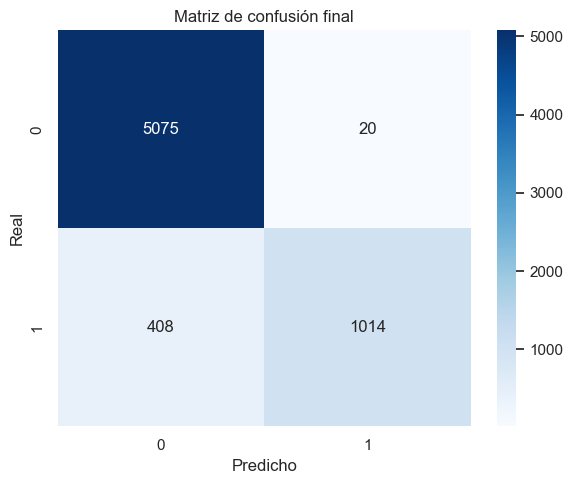

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5095
           1       0.98      0.71      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.85      0.89      6517
weighted avg       0.94      0.93      0.93      6517



In [90]:
y_pred_final = (y_proba_final >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión final")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "confusion_matrix.png", dpi=160)
plt.show()

print(classification_report(y_test, y_pred_final, zero_division=0))

In [91]:
metricas_finales = {
    "Modelo": "Random Forest",
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final, zero_division=0),
    "Recall": recall_score(y_test, y_pred_final, zero_division=0),
    "F1": f1_score(y_test, y_pred_final, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_proba_final),
}

pd.DataFrame([metricas_finales]).to_csv(ASSETS_DIR / "metricas_modelo_final.csv", index=False)
pd.DataFrame(classification_report(y_test, y_pred_final, output_dict=True, zero_division=0)).transpose().to_csv(
    ASSETS_DIR / "classification_report_final.csv"
)

metricas_finales

{'Modelo': 'Random Forest',
 'Threshold': 0.55,
 'Accuracy': 0.9343256099432254,
 'Precision': 0.9806576402321083,
 'Recall': 0.7130801687763713,
 'F1': 0.8257328990228013,
 'ROC_AUC': 0.9292164762618547}

## Interpretación del modelo con SHAP

        Se mantiene el análisis SHAP para explicar el Random Forest seleccionado. Como el modelo final está dentro de un pipeline, primero se transforma el conjunto de prueba con el preprocesador y luego se aplica `TreeExplainer` sobre el estimador Random Forest.

In [92]:
import shap

preprocessor_final = final_pipeline.named_steps["preprocessor"]
random_forest_final = final_pipeline.named_steps["model"]

X_test_preprocessed = preprocessor_final.transform(X_test)
feature_names = preprocessor_final.get_feature_names_out()

X_test_preprocessed = pd.DataFrame(
    X_test_preprocessed,
    columns=feature_names,
    index=X_test.index
)

X_shap = X_test_preprocessed.sample(min(500, len(X_test_preprocessed)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(random_forest_final)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_arr = np.array(shap_values)
    shap_values_class1 = shap_values_arr[:, :, 1] if shap_values_arr.ndim == 3 else shap_values_arr

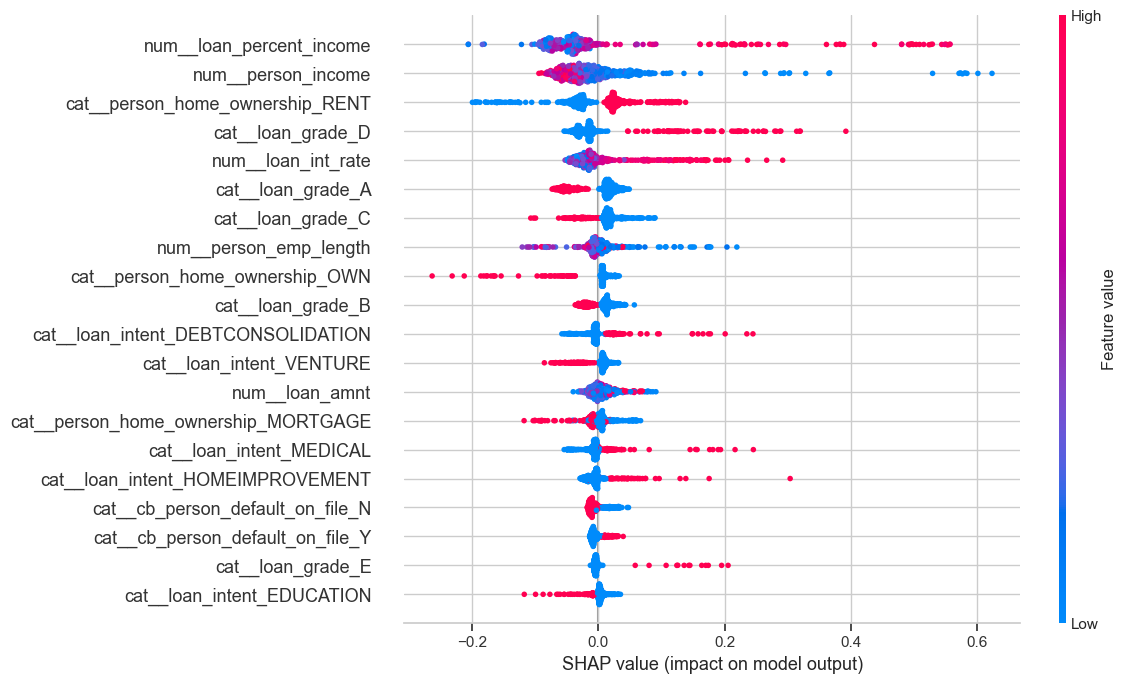

In [93]:
shap.summary_plot(
    shap_values_class1,
    X_shap,
    show=False
)

plt.gcf().set_size_inches(12, 7)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "shap_summary.png", dpi=160, bbox_inches="tight")
plt.show()

In [94]:
shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values_class1).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.to_csv(ASSETS_DIR / "shap_importance.csv", index=False)
shap_importance.head(10)

,feature,mean_abs_shap
5,num__loan_percent_income,0.083221
1,num__person_income,0.050397
10,cat__person_home_ownership_RENT,0.044682
20,cat__loan_grade_D,0.042444
4,num__loan_int_rate,0.035888
17,cat__loan_grade_A,0.028524
19,cat__loan_grade_C,0.021729
2,num__person_emp_length,0.018645
9,cat__person_home_ownership_OWN,0.017218
18,cat__loan_grade_B,0.016803


### Explicación local de una predicción

        El gráfico waterfall permite revisar una observación específica y observar cómo cada variable desplaza la predicción hacia mayor o menor riesgo.

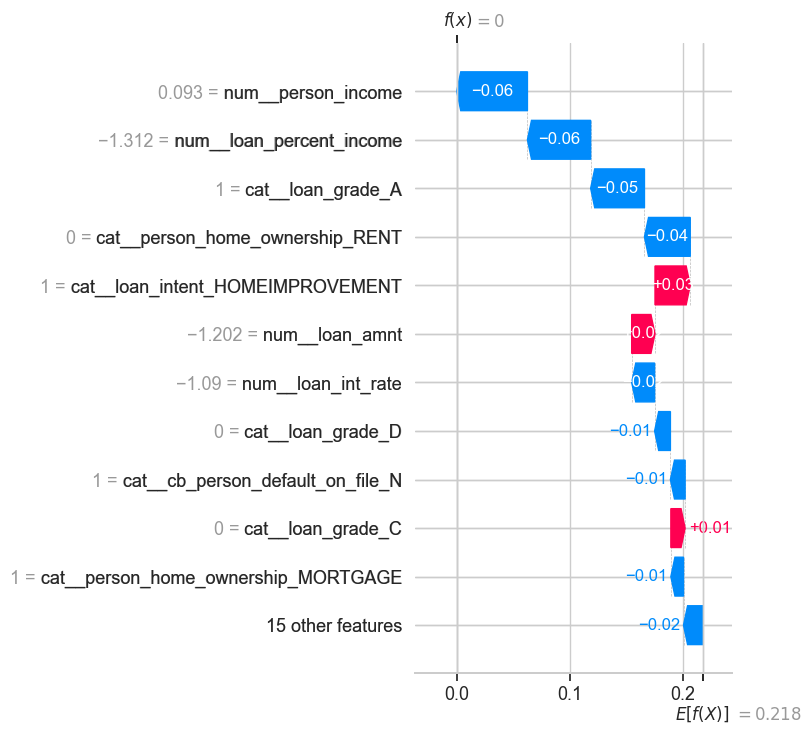

In [95]:
fila = X_shap.iloc[[0]]
shap_row_all = explainer.shap_values(fila)

if isinstance(shap_row_all, list):
    shap_row = shap_row_all[1][0]
    base_value = explainer.expected_value[1]
else:
    shap_row_arr = np.array(shap_row_all)
    if shap_row_arr.ndim == 3:
        shap_row = shap_row_arr[0, :, 1]
        base_value = explainer.expected_value[1]
    else:
        shap_row = shap_row_arr[0]
        base_value = explainer.expected_value

exp = shap.Explanation(
    values=shap_row,
    base_values=base_value,
    data=fila.iloc[0].values,
    feature_names=fila.columns
)

shap.plots.waterfall(exp, max_display=12, show=False)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "shap_waterfall.png", dpi=160, bbox_inches="tight")
plt.show()

## Exportación del pipeline final

        Se guarda el pipeline completo para que la app Dash use las mismas transformaciones entrenadas en el notebook. También se guarda el threshold optimizado y las métricas finales.

In [96]:
joblib.dump(final_pipeline, "../app/model.pkl")
joblib.dump(
    {"threshold": best_threshold, "metrics": metricas_finales},
    "../app/model_metadata.pkl"
)

metadata = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target": target,
    "random_state": RANDOM_STATE,
    "best_threshold": best_threshold,
}

(ASSETS_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

print("Pipeline final y métricas exportadas correctamente.")

Pipeline final y métricas exportadas correctamente.


## Conclusión de la etapa de mejora del modelo

        La segunda iteración amplía la comparación técnica sin cambiar el enfoque central del proyecto. Random Forest se mantiene como modelo final porque obtiene el mejor equilibrio entre F1-score, ROC-AUC, estabilidad e interpretabilidad sobre datos tabulares. Las técnicas de balanceo y el ajuste de threshold permiten observar con mayor claridad el trade-off entre precision y recall, dejando una base más sólida para justificar decisiones de negocio y futuras mejoras.